# RNN Models for Microsoft Stock Forecasting

## Purpose

This notebook trains recurrent neural network models for the CA2 Microsoft stock forecasting task. The objective is to predict the next trading day's adjusted Close price for MSFT using the previous 60 trading days of Open, High, Low, Close, and Volume features.

RNN-style models are suitable here because the input is ordered sequential data. The model reads a recent window of trading days and produces one forecast for the next trading day.

## Link to the project workflow

This is the Modelling stage for the recurrent models. Notebook 01 prepared the supervised windows and scalers. This notebook trains LSTM and GRU models, evaluates them against a naive last-close baseline, and saves predictions and metrics for Notebook 04.


In [1]:
from pathlib import Path
import copy
import random

import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from IPython.display import Markdown, display
from matplotlib import pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from torch.utils.data import DataLoader, TensorDataset

# Resolve project paths robustly whether the notebook is run from the repo root or notebooks/.
CWD = Path.cwd().resolve()
if (CWD / "data").exists() and (CWD / "notebooks").exists():
    PROJECT_ROOT = CWD
elif CWD.name == "notebooks" and (CWD.parent / "data").exists():
    PROJECT_ROOT = CWD.parent
else:
    PROJECT_ROOT = CWD.parent if (CWD.parent / "data").exists() else CWD

DATA_DIR = PROJECT_ROOT / "data"
MODELS_DIR = PROJECT_ROOT / "models"
TABLES_DIR = PROJECT_ROOT / "outputs" / "tables"
PLOTS_DIR = PROJECT_ROOT / "outputs" / "plots"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

WINDOW_SIZE = 60
INPUT_DIM = 5
OUTPUT_DIM = 1
CLOSE_FEATURE_INDEX = 3
BATCH_SIZE = 64
RANDOM_SEED = 42


def set_random_seeds(seed=RANDOM_SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    try:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    except Exception:
        pass


set_random_seeds()

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Project root: {PROJECT_ROOT}")
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")


Project root: /Users/ugurercan/Desktop/DBS MSc in AI Classes/Deep Learning/CA2/MSFT_Forecasting
Using device: mps
PyTorch version: 2.11.0


## Relationship to Notebook 01 data preparation

Notebook 01 downloads MSFT daily data from Yahoo Finance, creates chronological train/validation/test splits, fits scalers only on the training split, and saves NumPy arrays for downstream modelling. Notebook 02 treats those files as fixed inputs and does not refit scalers or recreate the split.

The target dates saved by Notebook 01 are important because recurrent model predictions must remain aligned with the actual next-day Close values when metrics and prediction CSVs are created.


In [2]:
# Load supervised windows, targets, target dates, and the Close scaler from Notebook 01.
X_train = np.load(DATA_DIR / "X_train.npy")
X_val = np.load(DATA_DIR / "X_val.npy")
X_test = np.load(DATA_DIR / "X_test.npy")
y_train = np.load(DATA_DIR / "y_train.npy")
y_val = np.load(DATA_DIR / "y_val.npy")
y_test = np.load(DATA_DIR / "y_test.npy")
train_dates = np.load(DATA_DIR / "train_dates.npy")
val_dates = np.load(DATA_DIR / "val_dates.npy")
test_dates = np.load(DATA_DIR / "test_dates.npy")
scaler_close = joblib.load(MODELS_DIR / "scaler_close.pkl")


def to_datetime_index(date_array):
    return pd.DatetimeIndex(pd.to_datetime(date_array))


def date_range_label(date_array):
    dates = to_datetime_index(date_array)
    return f"{dates.min().date()} to {dates.max().date()}"


def validate_split(name, X, y, dates):
    assert X.ndim == 3, f"{name}: X must be 3D. Found shape {X.shape}."
    assert y.ndim == 1, f"{name}: y must be 1D. Found shape {y.shape}."
    assert X.shape[1:] == (WINDOW_SIZE, INPUT_DIM), f"{name}: expected X feature dimensions {(WINDOW_SIZE, INPUT_DIM)}, found {X.shape[1:]}"
    assert len(X) == len(y), f"{name}: X and y lengths do not match."
    assert len(y) == len(dates), f"{name}: y and date lengths do not match."
    pd_dates = to_datetime_index(dates)
    assert pd_dates.is_monotonic_increasing, f"{name}: target dates are not chronological."
    assert pd_dates.is_unique, f"{name}: target dates are not unique."
    assert not np.isnan(X).any(), f"{name}: X contains NaN values."
    assert not np.isnan(y).any(), f"{name}: y contains NaN values."


validate_split("Train", X_train, y_train, train_dates)
validate_split("Validation", X_val, y_val, val_dates)
validate_split("Test", X_test, y_test, test_dates)
assert len(X_test) == 616, f"Expected X_test length 616 after rerunning Notebook 01; found {len(X_test)}."

loaded_shapes = {
    "X_train": X_train.shape,
    "X_val": X_val.shape,
    "X_test": X_test.shape,
    "y_train": y_train.shape,
    "y_val": y_val.shape,
    "y_test": y_test.shape,
}

date_ranges = {
    "Train": date_range_label(train_dates),
    "Validation": date_range_label(val_dates),
    "Test": date_range_label(test_dates),
}

print("Loaded shapes:")
for name, shape in loaded_shapes.items():
    print(f"- {name}: {shape}")

print("\nTarget date ranges:")
for split, date_range in date_ranges.items():
    print(f"- {split}: {date_range}")


Loaded shapes:
- X_train: (2810, 60, 5)
- X_val: (615, 60, 5)
- X_test: (616, 60, 5)
- y_train: (2810,)
- y_val: (615,)
- y_test: (616,)

Target date ranges:
- Train: 2010-03-31 to 2021-05-27
- Validation: 2021-05-28 to 2023-11-06
- Test: 2023-11-07 to 2026-04-23


Notebook 01 fits `MinMaxScaler` only on the training period. This avoids leakage because validation and test observations are transformed using parameters learned before those periods.

Values in validation or test can therefore fall outside `[0, 1]`. This is not an error and not leakage. It is evidence of scale shift and non-stationarity, which is common in equity prices over long time periods. For LSTM and GRU models trained mostly on lower historical price ranges, this shift can make test generalisation harder.


In [3]:
scaled_range_summary_path = TABLES_DIR / "scaled_range_summary.csv"
if scaled_range_summary_path.exists():
    scaled_range_summary = pd.read_csv(scaled_range_summary_path)
    print(f"Loaded scaled range summary from {scaled_range_summary_path}")
    display(scaled_range_summary)
else:
    scaled_range_summary = None
    print(f"No scaled range summary found at {scaled_range_summary_path}")


Loaded scaled range summary from /Users/ugurercan/Desktop/DBS MSc in AI Classes/Deep Learning/CA2/MSFT_Forecasting/outputs/tables/scaled_range_summary.csv


,Feature,train_min,train_max,val_min,val_max,test_min,test_max,val_outside_0_1,test_outside_0_1
0,Open,0.0,1.0,0.830178,1.441053,1.415638,2.287723,True,True
1,High,0.0,1.0,0.836692,1.453330,1.438530,2.275310,True,True
2,Low,0.0,1.0,0.818265,1.417185,1.397868,2.242267,True,True
3,Close,0.0,1.0,0.815467,1.429655,1.429335,2.232370,True,True
4,Volume,0.0,1.0,0.005692,0.266128,-0.005033,0.389332,False,True


## Naive baseline

The naive baseline predicts that the next trading day's Close will be equal to the last known Close in the 60-day input window. This is a strong baseline for one-step-ahead stock price forecasting because daily prices often move by a relatively small amount compared with the level of the price.

The Close feature is at index `3` in the input arrays, matching the feature order prepared in Notebook 01.


In [4]:
def inverse_close(scaled_values):
    values = np.asarray(scaled_values).reshape(-1, 1)
    return scaler_close.inverse_transform(values).reshape(-1)


actual_val = inverse_close(y_val)
actual_test = inverse_close(y_test)
previous_close_val = inverse_close(X_val[:, -1, CLOSE_FEATURE_INDEX])
previous_close_test = inverse_close(X_test[:, -1, CLOSE_FEATURE_INDEX])
naive_val = previous_close_val.copy()
naive_test = previous_close_test.copy()

print("Naive baseline prepared for validation and test sets.")
print(f"Validation samples: {len(naive_val)}")
print(f"Test samples: {len(naive_test)}")
print("First five test actual/previous-close pairs:")
display(pd.DataFrame({"Actual": actual_test[:5], "Previous_Close": previous_close_test[:5], "Naive": naive_test[:5]}))


Naive baseline prepared for validation and test sets.
Validation samples: 615
Test samples: 616
First five test actual/previous-close pairs:


,Actual,Previous_Close,Naive
0,353.706665,349.782349,349.782349
1,356.326172,353.706665,353.706665
2,353.863647,356.326172,356.326172
3,362.673645,353.863647,353.863647
4,359.740326,362.673645,362.673645


## LSTM architecture

The LSTM is used as a many-to-one sequence forecaster. Each sample has shape `60 time steps x 5 features`, and the model outputs one scaled next-day Close value.

LSTMs use input, forget, and output gates together with a cell state. The simple intuition is that the gates help the network decide what recent information to keep, update, or forget while reading the 60-day sequence.


In [5]:
class LSTMModel(nn.Module):
    def __init__(self, input_dim=INPUT_DIM, hidden_dim=64, num_layers=2, output_dim=OUTPUT_DIM, dropout=0.2):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.output_dim = output_dim
        self.dropout = dropout if num_layers > 1 else 0.0
        self.lstm = nn.LSTM(
            input_dim,
            hidden_dim,
            num_layers,
            batch_first=True,
            dropout=self.dropout,
        )
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim, device=x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim, device=x.device)
        out, _ = self.lstm(x, (h0, c0))
        return self.fc(out[:, -1, :])


def count_trainable_parameters(model):
    return sum(param.numel() for param in model.parameters() if param.requires_grad)


example_lstm = LSTMModel()
print(f"Default LSTM trainable parameters: {count_trainable_parameters(example_lstm):,}")


Default LSTM trainable parameters: 51,521


## GRU architecture

The GRU is also used as a many-to-one sequence forecaster with the same input and output shapes as the LSTM. This makes the comparison fair because both recurrent models use the same data windows and target.

GRUs use update and reset gates. They are usually simpler than LSTMs because they do not maintain a separate cell state, but they can still learn temporal dependencies in the input sequence.


In [6]:
class GRUModel(nn.Module):
    def __init__(self, input_dim=INPUT_DIM, hidden_dim=64, num_layers=2, output_dim=OUTPUT_DIM, dropout=0.2):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.output_dim = output_dim
        self.dropout = dropout if num_layers > 1 else 0.0
        self.gru = nn.GRU(
            input_dim,
            hidden_dim,
            num_layers,
            batch_first=True,
            dropout=self.dropout,
        )
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim, device=x.device)
        out, _ = self.gru(x, h0)
        return self.fc(out[:, -1, :])


example_gru = GRUModel()
print(f"Default GRU trainable parameters: {count_trainable_parameters(example_gru):,}")


Default GRU trainable parameters: 38,657


## Training strategy

The chronological train/validation/test split has already been handled in Notebook 01. Training windows are shuffled inside mini-batches because stochastic optimisation benefits from mixed batches and this does not change the already-defined time split. Validation and test loaders are not shuffled so predictions stay aligned with dates.

Main training choices:

- input shape: `60 x 5`
- output: one scaled next-day Close value
- batch size: `64`
- optimiser: Adam with small weight decay
- losses compared during tuning: MSE loss and Smooth L1 loss
- regularisation: dropout candidates, learning-rate reduction, gradient clipping, and early stopping

The validation set is used for model selection. The test set is kept for final out-of-sample evaluation.


In [7]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_generator = torch.Generator().manual_seed(RANDOM_SEED)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, generator=train_generator)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")


Train batches: 44
Validation batches: 10
Test batches: 10


In [8]:
def make_loss(loss_name):
    if loss_name == "MSELoss":
        return nn.MSELoss()
    if loss_name == "SmoothL1Loss":
        return nn.SmoothL1Loss(beta=1.0)
    raise ValueError(f"Unknown loss function: {loss_name}")


def copy_state_dict_to_cpu(model):
    return {name: value.detach().cpu().clone() for name, value in model.state_dict().items()}


def train_model(model, train_loader, val_loader, lr, loss_name, num_epochs=80, patience=10, weight_decay=1e-5):
    criterion = make_loss(loss_name)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=4,
        min_lr=1e-5,
    )

    train_losses = []
    val_losses = []
    best_val_loss = float("inf")
    best_state_dict = copy_state_dict_to_cpu(model)
    epochs_without_improvement = 0

    for epoch in range(1, num_epochs + 1):
        model.train()
        train_loss_total = 0.0
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad(set_to_none=True)
            output = model(X_batch)
            loss = criterion(output, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss_total += loss.item() * X_batch.size(0)

        train_loss = train_loss_total / len(train_loader.dataset)
        train_losses.append(train_loss)

        model.eval()
        val_loss_total = 0.0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)
                output = model(X_batch)
                loss = criterion(output, y_batch)
                val_loss_total += loss.item() * X_batch.size(0)

        val_loss = val_loss_total / len(val_loader.dataset)
        val_losses.append(val_loss)
        scheduler.step(val_loss)

        if val_loss < best_val_loss - 1e-8:
            best_val_loss = val_loss
            best_state_dict = copy_state_dict_to_cpu(model)
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epoch == 1 or epoch % 10 == 0:
            current_lr = optimizer.param_groups[0]["lr"]
            print(
                f"Epoch {epoch:03d}/{num_epochs} | "
                f"train_loss={train_loss:.6f} | val_loss={val_loss:.6f} | lr={current_lr:.6f}"
            )

        if epochs_without_improvement >= patience:
            print(f"Early stopping at epoch {epoch} with best validation loss {best_val_loss:.6f}")
            break

    model.load_state_dict(best_state_dict)
    model.eval()
    return train_losses, val_losses, best_val_loss, best_state_dict


def predict_scaled(model, data_loader):
    model.eval()
    preds = []
    actuals = []
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            output = model(X_batch.to(device)).cpu().numpy()
            preds.append(output.reshape(-1))
            actuals.append(y_batch.numpy().reshape(-1))
    return np.concatenate(actuals), np.concatenate(preds)


def predict_dollar(model, data_loader):
    y_true_scaled, y_pred_scaled = predict_scaled(model, data_loader)
    return inverse_close(y_true_scaled), inverse_close(y_pred_scaled)


def plot_learning_curves(train_losses, val_losses, title, save_path):
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label="Training loss", linewidth=2)
    plt.plot(val_losses, label="Validation loss", linewidth=2)
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()


## Evaluation metrics

The models are trained on scaled targets, but model selection and final reporting use dollar-space metrics after inverse transformation. RMSE and MAE are easier to interpret in USD, while MAPE and R2 provide relative and variance-explained views.

`Directional_Accuracy` checks whether the predicted movement direction matches the actual movement direction relative to the previous known Close from the input window.


In [9]:
def calculate_metrics(y_true, y_pred, previous_close):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    previous_close = np.asarray(previous_close).reshape(-1)

    assert len(y_true) == len(y_pred) == len(previous_close), "Metric arrays must have matching lengths."

    mse = mean_squared_error(y_true, y_pred)
    rmse = float(np.sqrt(mse))
    mae = mean_absolute_error(y_true, y_pred)
    nonzero_mask = y_true != 0
    mape = float(np.mean(np.abs((y_true[nonzero_mask] - y_pred[nonzero_mask]) / y_true[nonzero_mask])) * 100) if np.any(nonzero_mask) else np.nan
    r2 = r2_score(y_true, y_pred)

    actual_direction = np.sign(y_true - previous_close)
    predicted_direction = np.sign(y_pred - previous_close)
    directional_accuracy = float(np.mean(actual_direction == predicted_direction) * 100) if len(y_true) else np.nan

    return {
        "MSE": float(mse),
        "RMSE": rmse,
        "MAE": float(mae),
        "MAPE": mape,
        "R2": float(r2),
        "Directional_Accuracy": directional_accuracy,
    }


naive_val_metrics = calculate_metrics(actual_val, naive_val, previous_close_val)
naive_test_metrics = calculate_metrics(actual_test, naive_test, previous_close_test)

print("Naive baseline metrics:")
display(pd.DataFrame([
    {"Model": "Naive Baseline", "Dataset": "Validation Set", **naive_val_metrics},
    {"Model": "Naive Baseline", "Dataset": "Test Set", **naive_test_metrics},
]))


Naive baseline metrics:


,Model,Dataset,MSE,RMSE,MAE,MAPE,R2,Directional_Accuracy
0,Naive Baseline,Validation Set,24.54878,4.954673,3.743972,1.359296,0.977924,0.162602
1,Naive Baseline,Test Set,39.60825,6.293509,4.390738,1.033303,0.981276,0.000000


## Hyperparameter tuning

A small candidate grid is used to keep runtime reasonable while still comparing recurrent capacity, dropout, learning rate, and loss function. The selected final model for each family is the candidate with the lowest validation RMSE in dollar space. If RMSE is tied, MAE is used next, then the simpler model with fewer trainable parameters.


In [10]:
candidate_configs = [
    {"CandidateName": "A", "hidden_dim": 64, "num_layers": 2, "dropout": 0.2, "lr": 1e-3, "loss_name": "MSELoss"},
    {"CandidateName": "B", "hidden_dim": 64, "num_layers": 2, "dropout": 0.2, "lr": 5e-4, "loss_name": "SmoothL1Loss"},
    {"CandidateName": "C", "hidden_dim": 64, "num_layers": 2, "dropout": 0.0, "lr": 5e-4, "loss_name": "SmoothL1Loss"},
    {"CandidateName": "D", "hidden_dim": 64, "num_layers": 2, "dropout": 0.1, "lr": 3e-4, "loss_name": "SmoothL1Loss"},
    {"CandidateName": "E", "hidden_dim": 32, "num_layers": 1, "dropout": 0.0, "lr": 1e-3, "loss_name": "MSELoss"},
    {"CandidateName": "F", "hidden_dim": 128, "num_layers": 2, "dropout": 0.2, "lr": 5e-4, "loss_name": "SmoothL1Loss"},
]


def instantiate_model(model_class, config):
    effective_dropout = config["dropout"] if config["num_layers"] > 1 else 0.0
    return model_class(
        input_dim=INPUT_DIM,
        hidden_dim=config["hidden_dim"],
        num_layers=config["num_layers"],
        output_dim=OUTPUT_DIM,
        dropout=effective_dropout,
    )


def tune_model_family(model_class, model_family):
    tuning_rows = []
    trial_results = []

    for candidate_order, config in enumerate(candidate_configs):
        set_random_seeds(RANDOM_SEED)
        effective_dropout = config["dropout"] if config["num_layers"] > 1 else 0.0
        print(f"\nTraining {model_family} Candidate {config['CandidateName']} with effective_dropout={effective_dropout}")

        model = instantiate_model(model_class, config).to(device)
        total_trainable_params = count_trainable_parameters(model)
        train_losses, val_losses, best_val_loss_scaled, best_state_dict = train_model(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            lr=config["lr"],
            loss_name=config["loss_name"],
        )

        val_actual_dollar, val_pred_dollar = predict_dollar(model, val_loader)
        val_metrics = calculate_metrics(val_actual_dollar, val_pred_dollar, previous_close_val)

        row = {
            "ModelFamily": model_family,
            "CandidateName": config["CandidateName"],
            "candidate_order": candidate_order,
            "hidden_dim": config["hidden_dim"],
            "num_layers": config["num_layers"],
            "dropout": config["dropout"],
            "effective_dropout": effective_dropout,
            "lr": config["lr"],
            "loss_name": config["loss_name"],
            "best_val_loss_scaled": float(best_val_loss_scaled),
            "val_RMSE_dollar": val_metrics["RMSE"],
            "val_MAE_dollar": val_metrics["MAE"],
            "val_MAPE": val_metrics["MAPE"],
            "val_R2": val_metrics["R2"],
            "val_Directional_Accuracy": val_metrics["Directional_Accuracy"],
            "total_trainable_params": total_trainable_params,
            "is_selected_final": False,
        }
        tuning_rows.append(row)
        trial_results.append({
            "config": config,
            "row": row,
            "model": model,
            "state_dict": best_state_dict,
            "train_losses": train_losses,
            "val_losses": val_losses,
        })
        print(
            f"{model_family} Candidate {config['CandidateName']} validation RMSE: "
            f"{val_metrics['RMSE']:.4f}, MAE: {val_metrics['MAE']:.4f}, "
            f"Directional_Accuracy: {val_metrics['Directional_Accuracy']:.2f}%"
        )

    selection_df = pd.DataFrame(tuning_rows).sort_values(
        ["val_RMSE_dollar", "val_MAE_dollar", "total_trainable_params", "candidate_order"]
    )
    selected_candidate = selection_df.iloc[0]["CandidateName"]

    for row in tuning_rows:
        row["is_selected_final"] = row["CandidateName"] == selected_candidate

    selected_result = next(result for result in trial_results if result["row"]["CandidateName"] == selected_candidate)
    selected_result["model"].load_state_dict(selected_result["state_dict"])
    selected_result["model"].eval()

    print(f"\nSelected {model_family} Candidate {selected_candidate}")
    print({key: selected_result["row"][key] for key in ["hidden_dim", "num_layers", "dropout", "effective_dropout", "lr", "loss_name", "val_RMSE_dollar"]})
    return tuning_rows, selected_result



Training LSTM Candidate A with effective_dropout=0.2


Epoch 001/80 | train_loss=0.017097 | val_loss=0.080200 | lr=0.001000


Epoch 010/80 | train_loss=0.000385 | val_loss=0.059212 | lr=0.001000


Epoch 020/80 | train_loss=0.000281 | val_loss=0.059753 | lr=0.000250
Early stopping at epoch 20 with best validation loss 0.059212
LSTM Candidate A validation RMSE: 56.9554, MAE: 25.3636, Directional_Accuracy: 51.22%

Training LSTM Candidate B with effective_dropout=0.2


Epoch 001/80 | train_loss=0.014735 | val_loss=0.037705 | lr=0.000500


...

Epoch 010/80 | train_loss=0.000119 | val_loss=0.030367 | lr=0.000250


Epoch 020/80 | train_loss=0.000099 | val_loss=0.030228 | lr=0.000125


Epoch 030/80 | train_loss=0.000096 | val_loss=0.029908 | lr=0.000125


Epoch 040/80 | train_loss=0.000096 | val_loss=0.030213 | lr=0.000125


Early stopping at epoch 46 with best validation loss 0.028846
LSTM Candidate F validation RMSE: 56.2206, MAE: 22.0004, Directional_Accuracy: 49.76%

Selected LSTM Candidate C
{'hidden_dim': 64, 'num_layers': 2, 'dropout': 0.0, 'effective_dropout': 0.0, 'lr': 0.0005, 'loss_name': 'SmoothL1Loss', 'val_RMSE_dollar': 18.263415278815852}


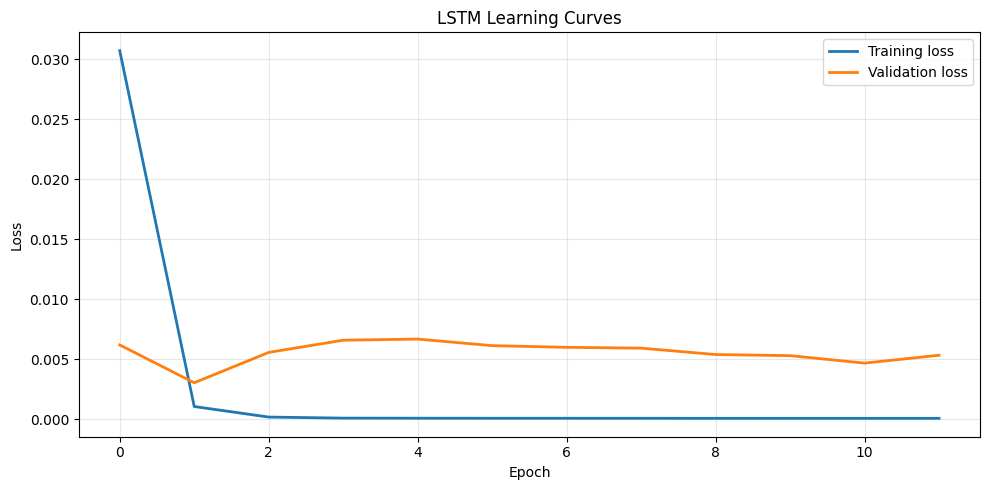

Saved selected LSTM weights to /Users/ugurercan/Desktop/DBS MSc in AI Classes/Deep Learning/CA2/MSFT_Forecasting/models/best_lstm.pth


In [11]:
lstm_tuning_rows, lstm_selected = tune_model_family(LSTMModel, "LSTM")
lstm_model = lstm_selected["model"]
lstm_model_path = MODELS_DIR / "best_lstm.pth"
torch.save(lstm_selected["state_dict"], lstm_model_path)
plot_learning_curves(
    lstm_selected["train_losses"],
    lstm_selected["val_losses"],
    "LSTM Learning Curves",
    PLOTS_DIR / "lstm_learning_curves.png",
)
print(f"Saved selected LSTM weights to {lstm_model_path}")



Training GRU Candidate A with effective_dropout=0.2


Epoch 001/80 | train_loss=0.022134 | val_loss=0.010996 | lr=0.001000


Epoch 010/80 | train_loss=0.000280 | val_loss=0.003421 | lr=0.000500


Early stopping at epoch 14 with best validation loss 0.002085
GRU Candidate A validation RMSE: 10.6887, MAE: 8.7628, Directional_Accuracy: 49.59%

Training GRU Candidate B with effective_dropout=0.2


Epoch 001/80 | train_loss=0.016668 | val_loss=0.001093 | lr=0.000500


...

Epoch 010/80 | train_loss=0.000135 | val_loss=0.001015 | lr=0.000250


Epoch 020/80 | train_loss=0.000113 | val_loss=0.000818 | lr=0.000250


Epoch 030/80 | train_loss=0.000097 | val_loss=0.000793 | lr=0.000063


Early stopping at epoch 32 with best validation loss 0.000747
GRU Candidate F validation RMSE: 9.0497, MAE: 7.4620, Directional_Accuracy: 49.43%



Selected GRU Candidate F
{'hidden_dim': 128, 'num_layers': 2, 'dropout': 0.2, 'effective_dropout': 0.2, 'lr': 0.0005, 'loss_name': 'SmoothL1Loss', 'val_RMSE_dollar': 9.04968492159676}


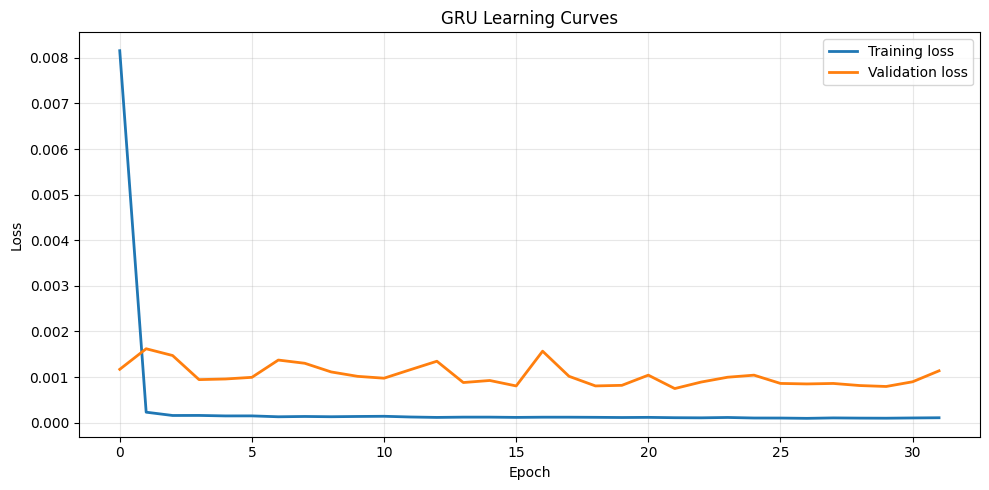

Saved selected GRU weights to /Users/ugurercan/Desktop/DBS MSc in AI Classes/Deep Learning/CA2/MSFT_Forecasting/models/best_gru.pth


In [12]:
gru_tuning_rows, gru_selected = tune_model_family(GRUModel, "GRU")
gru_model = gru_selected["model"]
gru_model_path = MODELS_DIR / "best_gru.pth"
torch.save(gru_selected["state_dict"], gru_model_path)
plot_learning_curves(
    gru_selected["train_losses"],
    gru_selected["val_losses"],
    "GRU Learning Curves",
    PLOTS_DIR / "gru_learning_curves.png",
)
print(f"Saved selected GRU weights to {gru_model_path}")


In [13]:
tuning_results_df = pd.DataFrame(lstm_tuning_rows + gru_tuning_rows)
tuning_columns = [
    "ModelFamily",
    "CandidateName",
    "hidden_dim",
    "num_layers",
    "dropout",
    "effective_dropout",
    "lr",
    "loss_name",
    "best_val_loss_scaled",
    "val_RMSE_dollar",
    "val_MAE_dollar",
    "val_MAPE",
    "val_R2",
    "val_Directional_Accuracy",
    "total_trainable_params",
    "is_selected_final",
]
tuning_results_df = tuning_results_df[tuning_columns]
tuning_results_path = TABLES_DIR / "rnn_tuning_results.csv"
tuning_results_df.to_csv(tuning_results_path, index=False)

selected_model_summary_rows = []
selected_config_rows = []
for selected, model_path_relative in [
    (lstm_selected, "../models/best_lstm.pth"),
    (gru_selected, "../models/best_gru.pth"),
]:
    row = selected["row"]
    selected_model_summary_rows.append({
        "model family": row["ModelFamily"],
        "input_dim": INPUT_DIM,
        "hidden_dim": row["hidden_dim"],
        "num_layers": row["num_layers"],
        "dropout": row["effective_dropout"],
        "output_dim": OUTPUT_DIM,
        "total_trainable_params": row["total_trainable_params"],
    })
    selected_config_rows.append({
        "ModelFamily": row["ModelFamily"],
        "CandidateName": row["CandidateName"],
        "hidden_dim": row["hidden_dim"],
        "num_layers": row["num_layers"],
        "dropout": row["dropout"],
        "effective_dropout": row["effective_dropout"],
        "lr": row["lr"],
        "loss_name": row["loss_name"],
        "input_dim": INPUT_DIM,
        "output_dim": OUTPUT_DIM,
        "model_path": model_path_relative,
        "total_trainable_params": row["total_trainable_params"],
        "selected_val_RMSE": row["val_RMSE_dollar"],
        "selected_val_MAE": row["val_MAE_dollar"],
        "selected_val_MAPE": row["val_MAPE"],
        "selected_val_R2": row["val_R2"],
        "selected_val_Directional_Accuracy": row["val_Directional_Accuracy"],
    })

selected_model_summary_df = pd.DataFrame(selected_model_summary_rows)
selected_configs_df = pd.DataFrame(selected_config_rows)
selected_configs_path = TABLES_DIR / "rnn_selected_model_configs.csv"
selected_configs_df.to_csv(selected_configs_path, index=False)

print(f"Saved tuning results to {tuning_results_path}")
print(f"Saved selected model configs to {selected_configs_path}")
print("Selected final model summaries:")
display(selected_model_summary_df)
display(selected_configs_df)


Saved tuning results to /Users/ugurercan/Desktop/DBS MSc in AI Classes/Deep Learning/CA2/MSFT_Forecasting/outputs/tables/rnn_tuning_results.csv
Saved selected model configs to /Users/ugurercan/Desktop/DBS MSc in AI Classes/Deep Learning/CA2/MSFT_Forecasting/outputs/tables/rnn_selected_model_configs.csv
Selected final model summaries:


,model family,input_dim,hidden_dim,num_layers,dropout,output_dim,total_trainable_params
0,LSTM,5,64,2,0.0,1,51521
1,GRU,5,128,2,0.2,1,151041


,ModelFamily,CandidateName,hidden_dim,num_layers,dropout,effective_dropout,lr,loss_name,input_dim,output_dim,model_path,total_trainable_params,selected_val_RMSE,selected_val_MAE,selected_val_MAPE,selected_val_R2,selected_val_Directional_Accuracy
0,LSTM,C,64,2,0.0,0.0,0.0005,SmoothL1Loss,5,1,../models/best_lstm.pth,51521,18.263415,15.321480,5.211174,0.700044,51.056911
1,GRU,F,128,2,0.2,0.2,0.0005,SmoothL1Loss,5,1,../models/best_gru.pth,151041,9.049685,7.461993,2.656246,0.926352,49.430894


### Tuning output interpretation

The tuning table records the recurrent architecture choices tested for each model family. The selected LSTM and GRU are chosen by validation RMSE in dollar space, with MAE and model size used only as tie-breakers.


## Results and diagnostic plots

The final evaluation compares the naive baseline, LSTM, and GRU on both validation and test sets. Validation results show the basis for model selection, while test results estimate out-of-sample generalisation after the models have been selected.


In [14]:
_, lstm_val_pred = predict_dollar(lstm_model, val_loader)
_, lstm_test_pred = predict_dollar(lstm_model, test_loader)
_, gru_val_pred = predict_dollar(gru_model, val_loader)
_, gru_test_pred = predict_dollar(gru_model, test_loader)

metrics_rows = []
for model_name, dataset_name, actual, predicted, previous in [
    ("Naive Baseline", "Validation Set", actual_val, naive_val, previous_close_val),
    ("Naive Baseline", "Test Set", actual_test, naive_test, previous_close_test),
    ("LSTM", "Validation Set", actual_val, lstm_val_pred, previous_close_val),
    ("LSTM", "Test Set", actual_test, lstm_test_pred, previous_close_test),
    ("GRU", "Validation Set", actual_val, gru_val_pred, previous_close_val),
    ("GRU", "Test Set", actual_test, gru_test_pred, previous_close_test),
]:
    metrics_rows.append({"Model": model_name, "Dataset": dataset_name, **calculate_metrics(actual, predicted, previous)})

rnn_metrics_df = pd.DataFrame(metrics_rows)[[
    "Model",
    "Dataset",
    "MSE",
    "RMSE",
    "MAE",
    "MAPE",
    "R2",
    "Directional_Accuracy",
]]
rnn_metrics_path = TABLES_DIR / "rnn_metrics.csv"
rnn_metrics_df.to_csv(rnn_metrics_path, index=False)

print(f"Saved RNN metrics to {rnn_metrics_path}")
display(rnn_metrics_df)


Saved RNN metrics to /Users/ugurercan/Desktop/DBS MSc in AI Classes/Deep Learning/CA2/MSFT_Forecasting/outputs/tables/rnn_metrics.csv


,Model,Dataset,MSE,RMSE,MAE,MAPE,R2,Directional_Accuracy
0,Naive Baseline,Validation Set,24.548780,4.954673,3.743972,1.359296,0.977924,0.162602
1,Naive Baseline,Test Set,39.608250,6.293509,4.390738,1.033303,0.981276,0.000000
2,LSTM,Validation Set,333.552338,18.263415,15.321480,5.211174,0.700044,51.056911
3,LSTM,Test Set,8556.407227,92.500850,86.769089,19.610025,-3.044969,46.915584
4,GRU,Validation Set,81.896797,9.049685,7.461993,2.656246,0.926352,49.430894
5,GRU,Test Set,1195.598022,34.577421,30.747349,6.889078,0.434791,47.402597


### Metric table interpretation

The metric table should be read separately for validation and test. Validation explains which recurrent configuration was selected, while test performance shows how the final selected models generalise to the later unseen period.


In [15]:
def make_prediction_frame(dates, actual, previous_close, naive, lstm_pred, gru_pred):
    frame = pd.DataFrame({
        "ds": to_datetime_index(dates).strftime("%Y-%m-%d"),
        "Actual": np.asarray(actual).reshape(-1),
        "Previous_Close": np.asarray(previous_close).reshape(-1),
        "Naive": np.asarray(naive).reshape(-1),
        "LSTM": np.asarray(lstm_pred).reshape(-1),
        "GRU": np.asarray(gru_pred).reshape(-1),
    })
    frame["Naive_Error"] = frame["Naive"] - frame["Actual"]
    frame["LSTM_Error"] = frame["LSTM"] - frame["Actual"]
    frame["GRU_Error"] = frame["GRU"] - frame["Actual"]
    return frame


rnn_val_predictions_df = make_prediction_frame(
    val_dates,
    actual_val,
    previous_close_val,
    naive_val,
    lstm_val_pred,
    gru_val_pred,
)
rnn_test_predictions_df = make_prediction_frame(
    test_dates,
    actual_test,
    previous_close_test,
    naive_test,
    lstm_test_pred,
    gru_test_pred,
)

assert len(rnn_val_predictions_df) == len(y_val)
assert len(rnn_test_predictions_df) == len(y_test) == 616

rnn_val_predictions_path = TABLES_DIR / "rnn_val_predictions.csv"
rnn_test_predictions_path = TABLES_DIR / "rnn_test_predictions.csv"
rnn_val_predictions_df.to_csv(rnn_val_predictions_path, index=False)
rnn_test_predictions_df.to_csv(rnn_test_predictions_path, index=False)

print(f"Saved validation predictions to {rnn_val_predictions_path}")
print(f"Saved test predictions to {rnn_test_predictions_path}")
display(rnn_test_predictions_df.head())


Saved validation predictions to /Users/ugurercan/Desktop/DBS MSc in AI Classes/Deep Learning/CA2/MSFT_Forecasting/outputs/tables/rnn_val_predictions.csv
Saved test predictions to /Users/ugurercan/Desktop/DBS MSc in AI Classes/Deep Learning/CA2/MSFT_Forecasting/outputs/tables/rnn_test_predictions.csv


,ds,Actual,Previous_Close,Naive,LSTM,GRU,Naive_Error,LSTM_Error,GRU_Error
0,2023-11-07,353.706665,349.782349,349.782349,304.173828,328.062073,-3.924316,-49.532837,-25.644592
1,2023-11-08,356.326172,353.706665,353.706665,305.735413,330.861328,-2.619507,-50.590759,-25.464844
2,2023-11-09,353.863647,356.326172,356.326172,307.327881,333.663025,2.462524,-46.535767,-20.200623
3,2023-11-10,362.673645,353.863647,353.863647,308.756287,336.046204,-8.809998,-53.917358,-26.627441
4,2023-11-13,359.740326,362.673645,362.673645,310.158630,338.438416,2.933319,-49.581696,-21.301910


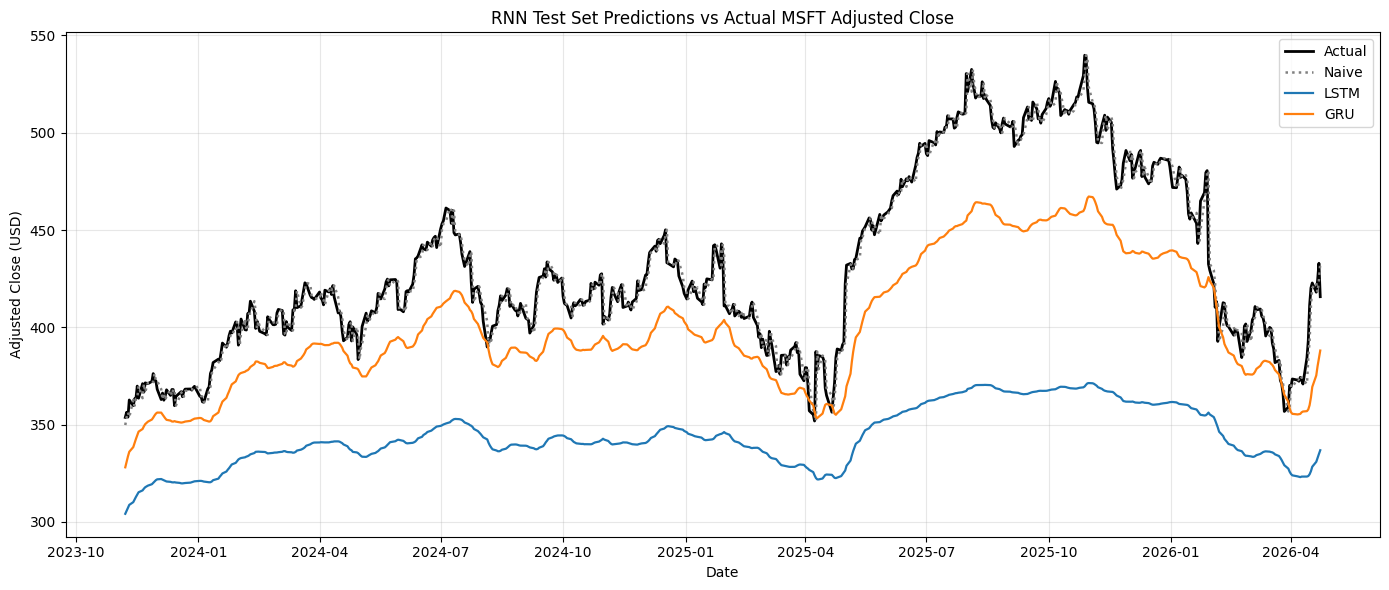

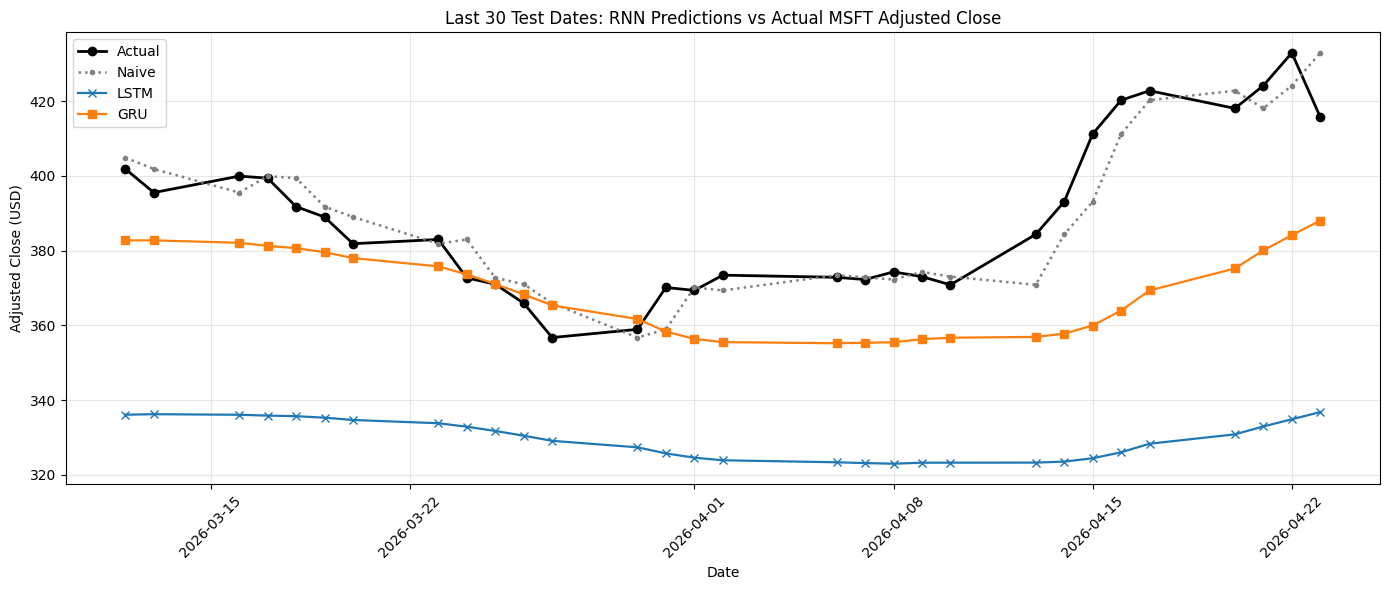

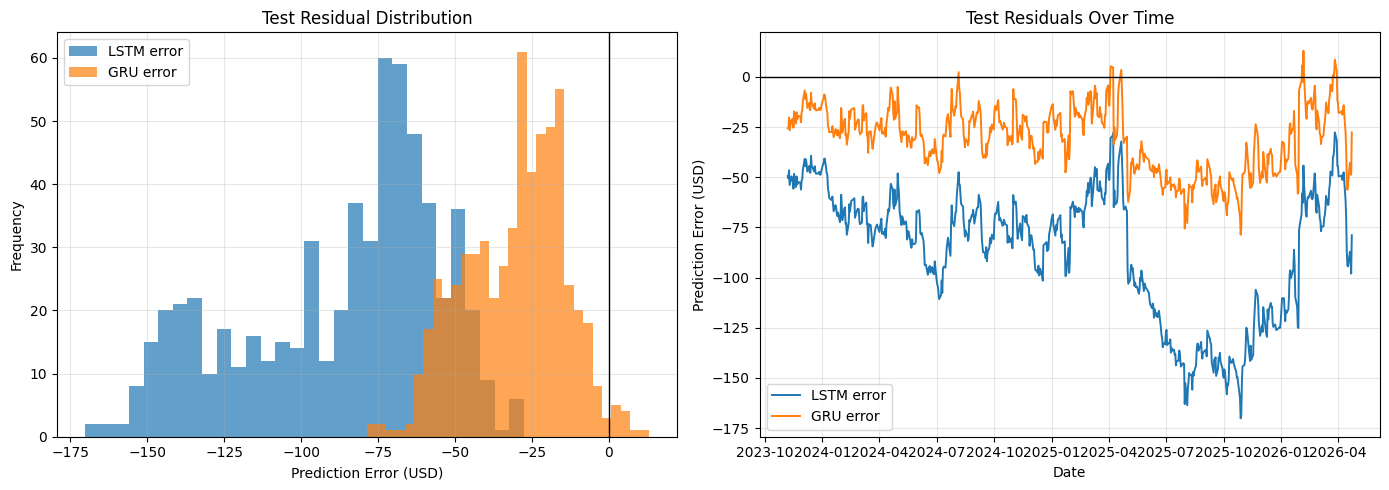

Saved diagnostic plots:
- /Users/ugurercan/Desktop/DBS MSc in AI Classes/Deep Learning/CA2/MSFT_Forecasting/outputs/plots/lstm_learning_curves.png
- /Users/ugurercan/Desktop/DBS MSc in AI Classes/Deep Learning/CA2/MSFT_Forecasting/outputs/plots/gru_learning_curves.png
- /Users/ugurercan/Desktop/DBS MSc in AI Classes/Deep Learning/CA2/MSFT_Forecasting/outputs/plots/rnn_test_predictions.png
- /Users/ugurercan/Desktop/DBS MSc in AI Classes/Deep Learning/CA2/MSFT_Forecasting/outputs/plots/rnn_zoomed_30d_predictions.png
- /Users/ugurercan/Desktop/DBS MSc in AI Classes/Deep Learning/CA2/MSFT_Forecasting/outputs/plots/rnn_residuals.png


In [16]:
test_plot_dates = to_datetime_index(test_dates)

plt.figure(figsize=(14, 6))
plt.plot(test_plot_dates, actual_test, label="Actual", color="black", linewidth=2)
plt.plot(test_plot_dates, naive_test, label="Naive", color="gray", linestyle=":", linewidth=1.8)
plt.plot(test_plot_dates, lstm_test_pred, label="LSTM", linewidth=1.6)
plt.plot(test_plot_dates, gru_test_pred, label="GRU", linewidth=1.6)
plt.title("RNN Test Set Predictions vs Actual MSFT Adjusted Close")
plt.xlabel("Date")
plt.ylabel("Adjusted Close (USD)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "rnn_test_predictions.png", dpi=150)
plt.show()

zoom_n = 30
zoom_dates = test_plot_dates[-zoom_n:]
plt.figure(figsize=(14, 6))
plt.plot(zoom_dates, actual_test[-zoom_n:], label="Actual", color="black", linewidth=2, marker="o")
plt.plot(zoom_dates, naive_test[-zoom_n:], label="Naive", color="gray", linestyle=":", linewidth=1.8, marker=".")
plt.plot(zoom_dates, lstm_test_pred[-zoom_n:], label="LSTM", linewidth=1.6, marker="x")
plt.plot(zoom_dates, gru_test_pred[-zoom_n:], label="GRU", linewidth=1.6, marker="s")
plt.title("Last 30 Test Dates: RNN Predictions vs Actual MSFT Adjusted Close")
plt.xlabel("Date")
plt.ylabel("Adjusted Close (USD)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "rnn_zoomed_30d_predictions.png", dpi=150)
plt.show()

lstm_errors = lstm_test_pred - actual_test
gru_errors = gru_test_pred - actual_test

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(lstm_errors, bins=30, alpha=0.7, label="LSTM error")
axes[0].hist(gru_errors, bins=30, alpha=0.7, label="GRU error")
axes[0].axvline(0, color="black", linewidth=1)
axes[0].set_title("Test Residual Distribution")
axes[0].set_xlabel("Prediction Error (USD)")
axes[0].set_ylabel("Frequency")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(test_plot_dates, lstm_errors, label="LSTM error", linewidth=1.4)
axes[1].plot(test_plot_dates, gru_errors, label="GRU error", linewidth=1.4)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Test Residuals Over Time")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Prediction Error (USD)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "rnn_residuals.png", dpi=150)
plt.show()

print("Saved diagnostic plots:")
for plot_name in [
    "lstm_learning_curves.png",
    "gru_learning_curves.png",
    "rnn_test_predictions.png",
    "rnn_zoomed_30d_predictions.png",
    "rnn_residuals.png",
]:
    print(f"- {PLOTS_DIR / plot_name}")


### Plot interpretation

The prediction plots show whether LSTM and GRU follow the level of the actual Close price or lag behind it. The residual plots are useful for spotting systematic under-prediction, over-prediction, or larger errors during specific market periods.


## Critical interpretation and limitations

The cell below interprets the final metrics after the notebook has been rerun. This is important because one-step-ahead stock price forecasting has a strong naive baseline, and visually plausible neural network predictions can still generalise poorly when the market regime and price scale change.


In [17]:
def metric_lookup(model, dataset, metric):
    mask = (rnn_metrics_df["Model"] == model) & (rnn_metrics_df["Dataset"] == dataset)
    return float(rnn_metrics_df.loc[mask, metric].iloc[0])


test_rmse_by_model = rnn_metrics_df[rnn_metrics_df["Dataset"] == "Test Set"].set_index("Model")["RMSE"].to_dict()
best_test_rmse_model = min(test_rmse_by_model, key=test_rmse_by_model.get)

lstm_val_rmse = metric_lookup("LSTM", "Validation Set", "RMSE")
lstm_test_rmse = metric_lookup("LSTM", "Test Set", "RMSE")
gru_val_rmse = metric_lookup("GRU", "Validation Set", "RMSE")
gru_test_rmse = metric_lookup("GRU", "Test Set", "RMSE")
lstm_direction = metric_lookup("LSTM", "Test Set", "Directional_Accuracy")
gru_direction = metric_lookup("GRU", "Test Set", "Directional_Accuracy")

better_rnn = "LSTM" if lstm_test_rmse < gru_test_rmse else "GRU"
direction_comment = (
    "close to random" if max(lstm_direction, gru_direction) < 55 else "meaningfully better than random"
)

critical_interpretation = f"""
### Critical interpretation and limitations

On the test set, the best RMSE among the evaluated Notebook 02 models is achieved by **{best_test_rmse_model}**. The naive baseline has test RMSE `{test_rmse_by_model['Naive Baseline']:.4f}`, LSTM has `{lstm_test_rmse:.4f}`, and GRU has `{gru_test_rmse:.4f}`. If the naive baseline is best, this should be stated clearly rather than treated as a modelling failure to hide; it shows how strong a last-close baseline is for one-step-ahead stock price forecasting.

Between the recurrent models, **{better_rnn}** has the lower test RMSE in this run. Validation and test performance should be compared carefully: LSTM validation/test RMSE is `{lstm_val_rmse:.4f}` / `{lstm_test_rmse:.4f}`, while GRU validation/test RMSE is `{gru_val_rmse:.4f}` / `{gru_test_rmse:.4f}`. A large gap indicates poor generalisation from the validation period into the later test period.

Directional accuracy is **{direction_comment}** in this run: LSTM test directional accuracy is `{lstm_direction:.2f}%` and GRU test directional accuracy is `{gru_direction:.2f}%`. This means the models should not be interpreted as reliable trading systems.

Notebook 01's scaled range summary shows scale shift and non-stationarity because validation and test values can move outside the training-fitted `[0, 1]` range. This helps explain why LSTM and GRU models trained on earlier price levels may struggle to generalise to the later test period. Residual or delta prediction could be considered as future work, but the main models here intentionally keep the direct scaled next-day Close target.
"""

display(Markdown(critical_interpretation))



### Critical interpretation and limitations

On the test set, the best RMSE among the evaluated Notebook 02 models is achieved by **Naive Baseline**. The naive baseline has test RMSE `6.2935`, LSTM has `92.5008`, and GRU has `34.5774`. If the naive baseline is best, this should be stated clearly rather than treated as a modelling failure to hide; it shows how strong a last-close baseline is for one-step-ahead stock price forecasting.

Between the recurrent models, **GRU** has the lower test RMSE in this run. Validation and test performance should be compared carefully: LSTM validation/test RMSE is `18.2634` / `92.5008`, while GRU validation/test RMSE is `9.0497` / `34.5774`. A large gap indicates poor generalisation from the validation period into the later test period.

Directional accuracy is **close to random** in this run: LSTM test directional accuracy is `46.92%` and GRU test directional accuracy is `47.40%`. This means the models should not be interpreted as reliable trading systems.

Notebook 01's scaled range summary shows scale shift and non-stationarity because validation and test values can move outside the training-fitted `[0, 1]` range. This helps explain why LSTM and GRU models trained on earlier price levels may struggle to generalise to the later test period. Residual or delta prediction could be considered as future work, but the main models here intentionally keep the direct scaled next-day Close target.


In [18]:
saved_model_paths = [MODELS_DIR / "best_lstm.pth", MODELS_DIR / "best_gru.pth"]
saved_table_paths = [
    TABLES_DIR / "rnn_metrics.csv",
    TABLES_DIR / "rnn_tuning_results.csv",
    TABLES_DIR / "rnn_selected_model_configs.csv",
    TABLES_DIR / "rnn_val_predictions.csv",
    TABLES_DIR / "rnn_test_predictions.csv",
]
saved_plot_paths = [
    PLOTS_DIR / "lstm_learning_curves.png",
    PLOTS_DIR / "gru_learning_curves.png",
    PLOTS_DIR / "rnn_test_predictions.png",
    PLOTS_DIR / "rnn_zoomed_30d_predictions.png",
    PLOTS_DIR / "rnn_residuals.png",
]

selected_lstm_config = selected_configs_df[selected_configs_df["ModelFamily"] == "LSTM"].iloc[0].to_dict()
selected_gru_config = selected_configs_df[selected_configs_df["ModelFamily"] == "GRU"].iloc[0].to_dict()

print("Notebook 02 completed successfully")
print("\nLoaded data shapes:")
for name, shape in loaded_shapes.items():
    print(f"- {name}: {shape}")

print("\nDate ranges:")
for split, date_range in date_ranges.items():
    print(f"- {split}: {date_range}")

print("\nSelected LSTM config:")
print(selected_lstm_config)
print(f"Best LSTM validation RMSE: {selected_lstm_config['selected_val_RMSE']:.4f}")

print("\nSelected GRU config:")
print(selected_gru_config)
print(f"Best GRU validation RMSE: {selected_gru_config['selected_val_RMSE']:.4f}")

print("\nTest RMSE:")
for model in ["Naive Baseline", "LSTM", "GRU"]:
    print(f"- {model}: {metric_lookup(model, 'Test Set', 'RMSE'):.4f}")

print("\nTest Directional_Accuracy:")
for model in ["LSTM", "GRU"]:
    print(f"- {model}: {metric_lookup(model, 'Test Set', 'Directional_Accuracy'):.2f}%")

print("\nSaved model paths:")
for path in saved_model_paths:
    print(f"- {path}")

print("\nSaved table paths:")
for path in saved_table_paths:
    print(f"- {path}")

print("\nSaved plot paths:")
for path in saved_plot_paths:
    print(f"- {path}")


Notebook 02 completed successfully

Loaded data shapes:
- X_train: (2810, 60, 5)
- X_val: (615, 60, 5)
- X_test: (616, 60, 5)
- y_train: (2810,)
- y_val: (615,)
- y_test: (616,)

Date ranges:
- Train: 2010-03-31 to 2021-05-27
- Validation: 2021-05-28 to 2023-11-06
- Test: 2023-11-07 to 2026-04-23

Selected LSTM config:
{'ModelFamily': 'LSTM', 'CandidateName': 'C', 'hidden_dim': 64, 'num_layers': 2, 'dropout': 0.0, 'effective_dropout': 0.0, 'lr': 0.0005, 'loss_name': 'SmoothL1Loss', 'input_dim': 5, 'output_dim': 1, 'model_path': '../models/best_lstm.pth', 'total_trainable_params': 51521, 'selected_val_RMSE': 18.263415278815852, 'selected_val_MAE': 15.321479797363281, 'selected_val_MAPE': 5.211174011230469, 'selected_val_R2': 0.7000438570976257, 'selected_val_Directional_Accuracy': 51.056910569105696}
Best LSTM validation RMSE: 18.2634

Selected GRU config:
{'ModelFamily': 'GRU', 'CandidateName': 'F', 'hidden_dim': 128, 'num_layers': 2, 'dropout': 0.2, 'effective_dropout': 0.2, 'lr': 0.0

## Notebook 02 summary

This notebook trained and evaluated LSTM and GRU models using the fixed 60-day OHLCV windows from Notebook 01. It also prepared a naive last-close baseline so the neural networks are compared against a realistic one-step forecasting benchmark.

Saved outputs include:

- selected LSTM and GRU model weights
- RNN tuning results and selected configuration tables
- validation and test prediction CSV files
- RNN metric tables and diagnostic plots

Notebook 03 adds a transformer-based PatchTST model. Notebook 04 uses the saved RNN and PatchTST outputs for the final model comparison.
